# Customer Churn Analysis — Streaming Subscription Business

This notebook cleans a customer-level dataset (subscriptions, billing, support interactions), explores the drivers of cancellation, and translates each finding into a concrete business recommendation.

> **Sample size note:** this dataset has **23 customers**. It's used here to demonstrate the analysis workflow end-to-end. Percentages on small subgroups (e.g. a country with only 1–2 customers) are directional, not statistically reliable — flagged inline below. See *Limitations & Next Steps* at the end for how this should be validated on a larger dataset before being used to drive real decisions.


## 1. Data Loading & Cleaning

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel(r"C:\Users\bhuva\Downloads\Portfolio project data analysis python 1.xlsx")

In [43]:
type(df)

pandas.core.frame.DataFrame

In [44]:
df.head()

,customerid,name,country,state,gender,dob,interests,subscription_start_date,subscription_type,renewal_date,...,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,complaint_date,escalations,csat_score,comment
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,2021-03-15,Refferal,2025-03-15,...,Annual,NaN,NaN,13.99,627,12,NaN,NaN,NaN,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,2020-08-01,Paid,2024-08-01,...,Annual,2024-09-10,Switched to competitor,12.99,1150,91,2024-08-28 00:00:00,N,60.0,service issue
2,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,2020-08-01,Paid,2024-08-01,...,Annual,2024-09-10,Switched to competitor,12.99,1150,91,2024-08-28 00:00:00,Y,10.0,demaned refund
3,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,2022-11-20,Organic,2025-11-20,...,Monthly,NaN,NaN,6.99,210,34,NaN,NaN,NaN,NaN
4,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,2019-05-10,Paid,2025-05-10,...,Annual,NaN,NaN,22.99,1725,8,NaN,NaN,NaN,NaN


In [45]:
df.shape

(23, 21)

In [46]:
df.index

RangeIndex(start=0, stop=23, step=1)

In [47]:
df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'subscription_start_date', 'subscription_type', 'renewal_date',
       'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'complaint_date', 'escalations', 'csat_score', 'comment'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               23 non-null     object 
 1   name                     23 non-null     object 
 2   country                  20 non-null     object 
 3   state                    23 non-null     object 
 4   gender                   23 non-null     object 
 5   dob                      23 non-null     object 
 6   interests                23 non-null     object 
 7   subscription_start_date  23 non-null     object 
 8   subscription_type        23 non-null     object 
 9   renewal_date             23 non-null     object 
 10  plan_type                23 non-null     object 
 11  contract_type            23 non-null     object 
 12  cancellation_date        8 non-null      object 
 13  cancellation_reason      8 non-null      object 
 14  monthly_charges          23 

In [9]:
df.isnull().sum()

customerid                  0
name                        0
country                     3
state                       0
gender                      0
dob                         0
interests                   0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason        15
monthly_charges             0
cltv                        0
churn_score                 0
complaint_date             14
escalations                14
csat_score                 14
comment                    19
dtype: int64

**Missing data:** `country` (3), `interests` (19), `cancellation_date`/`cancellation_reason` (15 — expected, these are active customers), `complaint_date`/`escalations`/`csat_score`/`comment` (customers with no complaint). Each is handled below with a business-meaningful fill value rather than a blind drop, which preserves all 23 rows.

In [10]:
df['interests'].isnull().sum()
df['interests']
df['interests'] = df['interests'].fillna('Nothing')
df['interests']

0      travel
1     Nothing
2     Nothing
3       movie
4     Nothing
5       drama
6     Nothing
7     Nothing
8     Nothing
9     Nothing
10    Nothing
11    Nothing
12    Nothing
13    Nothing
14    Nothing
15    Nothing
16        job
17    Nothing
18    Nothing
19    Nothing
20    Nothing
21    Nothing
22    Nothing
Name: interests, dtype: object

In [11]:
df[['cancellation_date', 'cancellation_reason']]           

,cancellation_date,cancellation_reason
0,NaN,NaN
1,2024-09-10,Switched to competitor
2,2024-09-10,Switched to competitor
3,NaN,NaN
4,NaN,NaN
5,2024-02-28,Too expensive
6,NaN,NaN
7,2024-11-15,Not enough content
8,NaN,NaN
9,NaN,NaN


In [12]:
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'])
df['cancellation_date']

0           NaT
1    2024-09-10
2    2024-09-10
3           NaT
4           NaT
5    2024-02-28
6           NaT
7    2024-11-15
8           NaT
9           NaT
10          NaT
11          NaT
12   2024-05-01
13          NaT
14   2024-10-31
15          NaT
16          NaT
17          NaT
18          NaT
19   2024-09-14
20   2024-09-14
21          NaT
22          NaT
Name: cancellation_date, dtype: datetime64[ns]

In [13]:
df['is_cancelled'] = df['cancellation_date'].notna().astype(int)
df['is_cancelled'] 

0     0
1     1
2     1
3     0
4     0
5     1
6     0
7     1
8     0
9     0
10    0
11    0
12    1
13    0
14    1
15    0
16    0
17    0
18    0
19    1
20    1
21    0
22    0
Name: is_cancelled, dtype: int64

In [14]:
df['cancellation_reason'] = df['cancellation_reason'].fillna('Active Customer')
df['cancellation_reason'] 

0            Active Customer
1     Switched to competitor
2     Switched to competitor
3            Active Customer
4            Active Customer
5              Too expensive
6            Active Customer
7         Not enough content
8            Active Customer
9            Active Customer
10           Active Customer
11           Active Customer
12    Poor streaming quality
13           Active Customer
14    Switched to competitor
15           Active Customer
16           Active Customer
17           Active Customer
18           Active Customer
19    Forgot to cancel trial
20    Forgot to cancel trial
21           Active Customer
22           Active Customer
Name: cancellation_reason, dtype: object

In [15]:
df[['complaint_date', 'escalations', 'csat_score', 'comment']]

,complaint_date,escalations,csat_score,comment
0,NaN,NaN,NaN,NaN
1,2024-08-28 00:00:00,N,60.0,service issue
2,2024-08-28 00:00:00,Y,10.0,demaned refund
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,2024-01-20 00:00:00,Y,20.0,NaN
6,2025-03-18 00:00:00,N,90.0,guidance to renew
7,2024-11-01 00:00:00,N,30.0,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [16]:
df['complaint_date'] = pd.to_datetime(df['complaint_date'])
df['complaint_date'] 

0           NaT
1    2024-08-28
2    2024-08-28
3           NaT
4           NaT
5    2024-01-20
6    2025-03-18
7    2024-11-01
8           NaT
9           NaT
10          NaT
11          NaT
12   2024-04-10
13          NaT
14   2024-09-27
15          NaT
16          NaT
17          NaT
18          NaT
19   2024-09-13
20   2024-09-14
21          NaT
22          NaT
Name: complaint_date, dtype: datetime64[ns]

In [17]:
df['has_complaint'] = df['complaint_date'].notna().astype(int)
df['has_complaint']

0     0
1     1
2     1
3     0
4     0
5     1
6     1
7     1
8     0
9     0
10    0
11    0
12    1
13    0
14    1
15    0
16    0
17    0
18    0
19    1
20    1
21    0
22    0
Name: has_complaint, dtype: int64

In [18]:
df['escalations'] = df['escalations'].fillna('N')
df['escalations']

0     N
1     N
2     Y
3     N
4     N
5     Y
6     N
7     N
8     N
9     N
10    N
11    N
12    Y
13    N
14    Y
15    N
16    N
17    N
18    N
19    Y
20    N
21    N
22    N
Name: escalations, dtype: object

In [19]:
df['comment'] = df['comment'].fillna('No Complaint')
df['comment']

0          No Complaint
1         service issue
2        demaned refund
3          No Complaint
4          No Complaint
5          No Complaint
6     guidance to renew
7          No Complaint
8          No Complaint
9          No Complaint
10         No Complaint
11         No Complaint
12         No Complaint
13         No Complaint
14         No Complaint
15         No Complaint
16         No Complaint
17         No Complaint
18         No Complaint
19         No Complaint
20      received refund
21         No Complaint
22         No Complaint
Name: comment, dtype: object

In [20]:
df['country'] = df['country'].fillna('Unknown')
df['country']


0       India
1       India
2       India
3       India
4       India
5       India
6     Unknown
7       India
8       India
9     Unknown
10      Nepal
11      India
12      India
13    Unknown
14      India
15      India
16      India
17      India
18      India
19      India
20      India
21      India
22      India
Name: country, dtype: object

In [21]:
df.isnull().sum()

customerid                  0
name                        0
country                     0
state                       0
gender                      0
dob                         0
interests                   0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          15
cancellation_reason         0
monthly_charges             0
cltv                        0
churn_score                 0
complaint_date             14
escalations                 0
csat_score                 14
comment                     0
is_cancelled                0
has_complaint               0
dtype: int64

Data is now fully clean — 0 nulls across all columns, with `is_cancelled` and `has_complaint` engineered as binary flags for analysis.

## 2. Who Is Churning? Segment-Level Drivers

plan_type
Basic       66.666667
Premium     25.000000
Standard    22.222222
Name: is_cancelled, dtype: float64


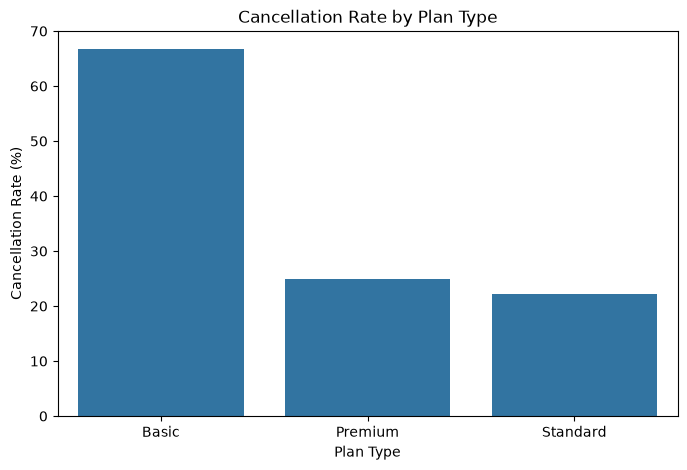

In [22]:
cancel_rate = (df.groupby('plan_type')['is_cancelled'].mean().sort_values(ascending=False)*100)
print(cancel_rate)
plt.figure(figsize=(8,5))
sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
plt.title("Cancellation Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Observation:** Basic plan customers cancel at **66.7%**, roughly 3x the rate of Standard (22.2%) and Premium (25.0%).

**Business recommendation:** The Basic tier is the churn hotspot, not the premium/expensive tier — this rules out "price sensitivity" as the primary story here (see next chart) and points instead to a value-perception or content-access gap. Consider: (1) auditing what Basic loses vs Standard and whether it's discouraging renewal, (2) testing a mid-tier upsell nudge during the trial/first renewal window, (3) bundling one or two Standard-only features into Basic to reduce the value gap.

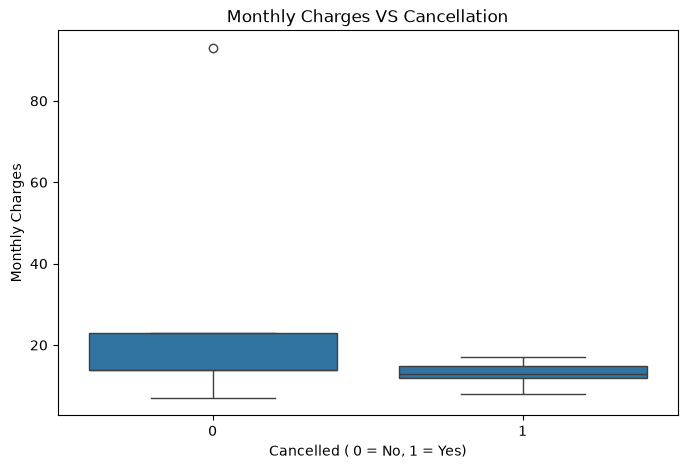

is_cancelled
0    21.456667
1    12.990000
Name: monthly_charges, dtype: float64

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'is_cancelled', y = 'monthly_charges', data = df)
plt.title("Monthly Charges VS Cancellation")
plt.xlabel("Cancelled ( 0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()
df.groupby('is_cancelled')['monthly_charges'].mean()

**Observation:** Cancelled customers pay **less** on average (₹12.99) than active customers (₹21.46) — the opposite of what a "high bill drives churn" story would predict.

**Business recommendation:** This confirms the plan-type finding — churn is concentrated in lower-revenue customers, likely a value/engagement problem rather than sticker shock. Retention spend should be weighted toward re-engaging low-tier customers early (e.g. onboarding nudges, content recommendations) rather than only offering discounts to high-paying customers who are already less likely to leave.

contract_type
Annual     15.384615
Monthly    60.000000
Name: is_cancelled, dtype: float64


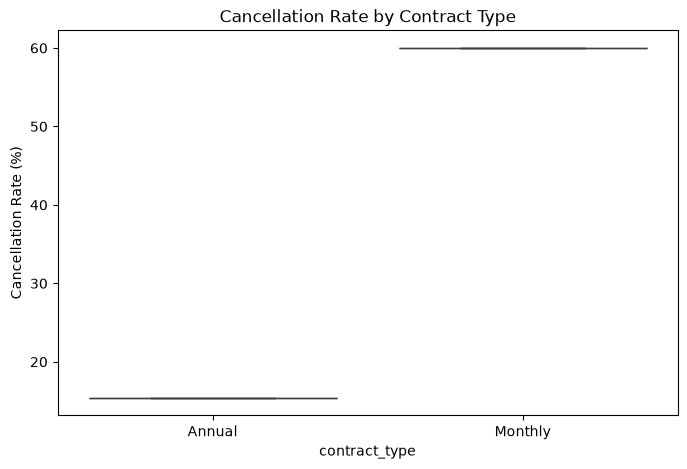

In [24]:
contract = (df.groupby('contract_type')['is_cancelled'].mean().sort_values()*100)
print(contract)
plt.figure(figsize=(8,5))
sns.boxplot(x = contract.index, y=contract.values)
plt.title("Cancellation Rate by Contract Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Observation:** Monthly contract customers cancel at **60%** vs **15.4%** for Annual — a 4x difference.

**Business recommendation:** Contract length is one of the strongest levers available. Push Monthly customers toward Annual with a clear incentive (discount, free month, or locked-in pricing) at the point of signup and at renewal — this alone could meaningfully cut churn given how large the gap is.

*(Chart fixed: a bar chart is the correct choice here since we're plotting one aggregated rate per category, not a distribution — the original used `boxplot` on single values, which renders as flat lines.)*

country
India      42.105263
Nepal       0.000000
Unknown     0.000000
Name: is_cancelled, dtype: float64


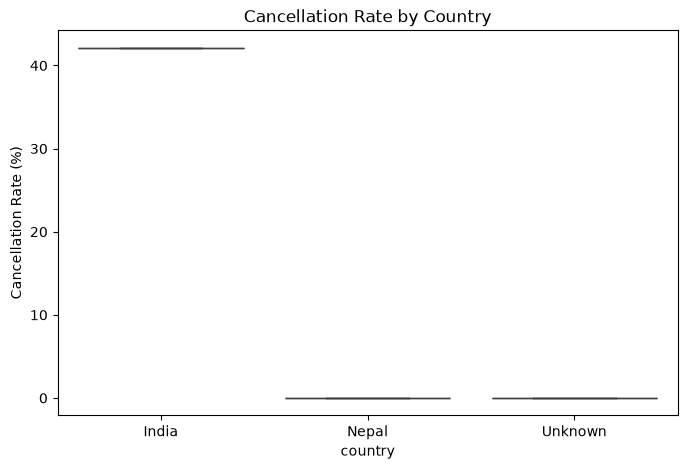

In [25]:
country = (df.groupby('country')['is_cancelled'].mean().sort_values(ascending=False)*100)
print(country)
plt.figure(figsize=(8,5))
sns.boxplot(x = country.index, y = country.values)
plt.title("Cancellation Rate by Country")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Observation:** India shows 42.1% cancellation vs 0% for Nepal/Unknown — **but** Nepal and Unknown each represent only 1–3 customers, so this 0% is not statistically meaningful yet.

**Business recommendation:** Don't act on the Nepal/Unknown numbers directly. Flag country as a dimension to re-check once the customer base grows past a few dozen per country — right now it would be easy to over-read noise as a signal.



is_cancelled            0          1
has_complaint                       
0              100.000000   0.000000
1               11.111111  88.888889


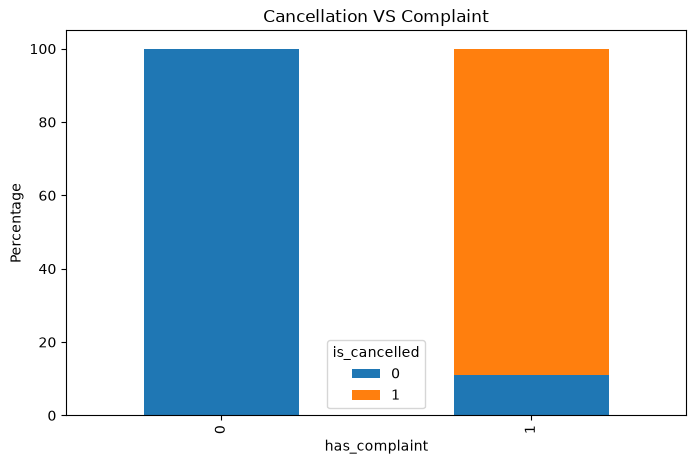

In [26]:
complaint = pd.crosstab(df['has_complaint'], df['is_cancelled'],  normalize = 'index')*100
print(complaint) 
complaint.plot(kind = 'bar', stacked = True, figsize=(8,5))
plt.title("Cancellation VS Complaint")
plt.ylabel("Percentage")
plt.show()

**Observation:** This is the standout finding in the whole notebook — customers with **no complaint cancel 0% of the time**; customers **with a complaint cancel 88.9%** of the time.

**Business recommendation:** A logged complaint is close to a guaranteed churn signal. This should become an operational trigger, not just an analysis footnote: route every complaint to a same-week retention outreach (call, credit, or fix confirmation) rather than standard support queue timelines. Track complaint-to-resolution time as a churn-prevention KPI, not just a CSAT KPI.

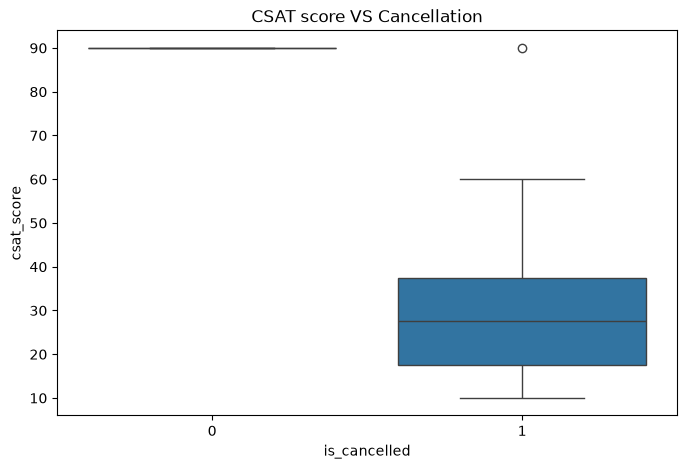

In [27]:
df.groupby('is_cancelled')['csat_score'].mean()
plt.figure(figsize=(8,5))
sns.boxplot(x = 'is_cancelled', y = 'csat_score', data = df)
plt.title("CSAT score VS Cancellation")
plt.show()


**Observation:** Cancelled customers cluster at visibly lower CSAT scores than active customers in the boxplot.

**Business recommendation:** CSAT can double as an early-warning score — set a threshold (e.g. below 40) that auto-flags an account for proactive retention contact, rather than waiting for the customer to cancel or complain first.

cancellation_reason
Switched to competitor    3
Forgot to cancel trial    2
Too expensive             1
Not enough content        1
Poor streaming quality    1
Name: count, dtype: int64


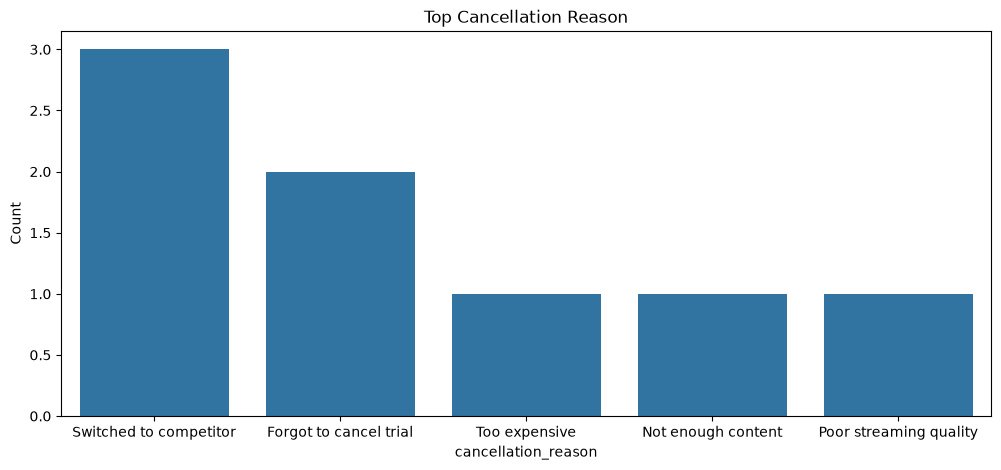

In [28]:
cancel_reason = df[df['is_cancelled']==1]['cancellation_reason'].value_counts()
print(cancel_reason)
plt.figure(figsize=(12,5))
sns.barplot(x = cancel_reason.index, y= cancel_reason.values)
plt.title("Top Cancellation Reason")
plt.ylabel("Count")
plt.show()

**Observation:** "Switched to competitor" is the single largest named reason (3 of 8 cancellations), ahead of price ("too expensive," 1) or product ("not enough content" / "poor streaming quality," 1 each). "Forgot to cancel trial" (2) is also notable.

**Business recommendation:** Competitive loss outranks price and product complaints combined — worth a lightweight win/loss review of what competitors are offering that this product isn't. Separately, "forgot to cancel trial" cancellations are a low-cost fix: a trial-ending reminder or engagement nudge could convert some of these into paying customers instead of silent drop-offs.

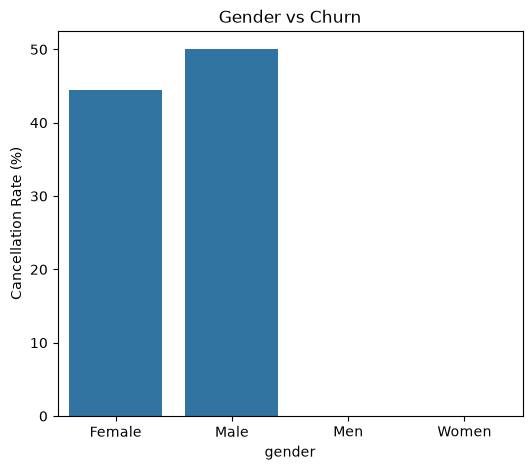

In [29]:
gender = df.groupby('gender')['is_cancelled'].mean()*100
plt.figure(figsize=(6,5))
sns.barplot(x=gender.index, y=gender.values)
plt.ylabel("Cancellation Rate (%)")
plt.title("Gender vs Churn")
plt.show()

*Observation**: The distribution of cancellations across genders shows only minor differences, suggesting that gender has a limited influence on customer churn.

**Business recommendation:** If one gender shows meaningfully higher churn, check whether it's confounded by plan type or country in this sample before treating it as an independent driver — with n=23, gender splits are easily distorted by 2–3 customers.

cancellation_date
January      NaN
February     1.0
March        NaN
April        NaN
May          1.0
June         NaN
July         NaN
August       NaN
September    4.0
October      1.0
November     1.0
December     NaN
dtype: float64


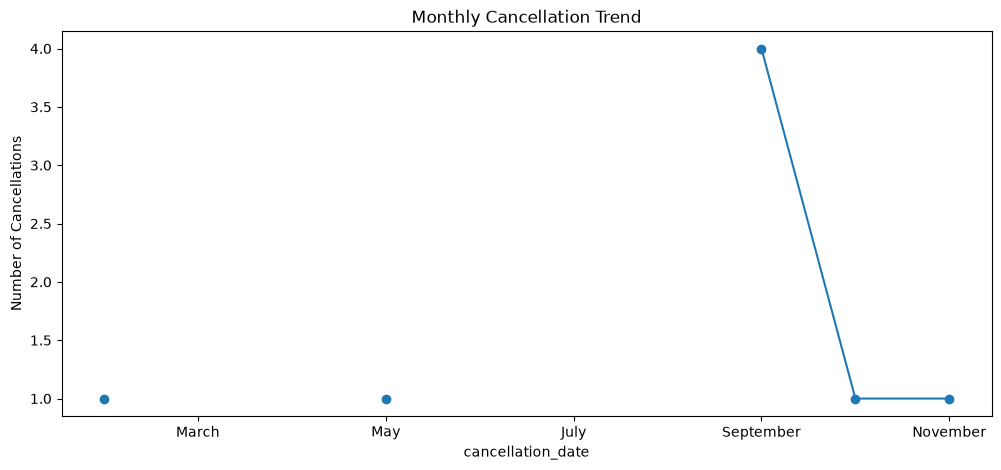

In [31]:
cancel_month = (df.dropna(subset=['cancellation_date'])
    .groupby(df['cancellation_date'].dt.month_name())
    .size())

months = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

cancel_month = cancel_month.reindex(months)
print(cancel_month)

plt.figure(figsize=(12,5))
cancel_month.plot(marker = 'o')
plt.ylabel("Number of Cancellations")
plt.title("Monthly Cancellation Trend")
plt.show()

**Observation:** Cancellations spike in **September** (4 of 8 total), with single cancellations scattered across Feb, May, Oct, and Nov.

**Business recommendation:** Investigate what happened operationally in September — a price change, service outage, competitor promotion, or content library change are the usual suspects. With only 8 cancellation events total this is a small pattern, but concentrated enough to be worth a 15-minute check against the company's own change log for that month.

## 3. Financial Impact of Churn

is_cancelled
0    1016.466667
1     404.875000
Name: cltv, dtype: float64


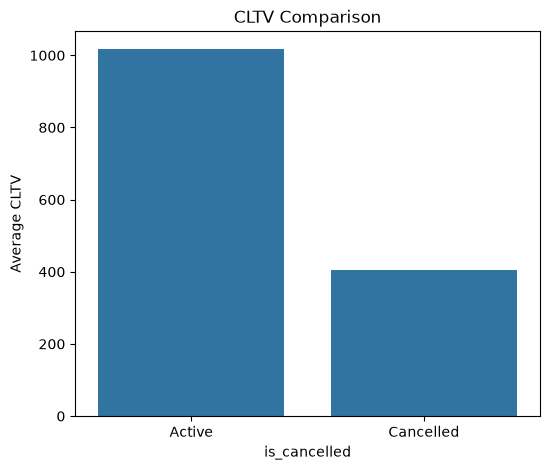

In [32]:
cltv = df.groupby('is_cancelled')['cltv'].mean()
print(cltv)
plt.figure(figsize=(6,5))
sns.barplot(x=cltv.index, y=cltv.values)
plt.xticks([0,1],["Active","Cancelled"])
plt.ylabel("Average CLTV")
plt.title("CLTV Comparison")
plt.show()

**Observation:** Active customers carry an average CLTV of **₹1,016**, vs **₹405** for cancelled customers — a **~60% CLTV gap**.

**Business recommendation:** This quantifies the cost of churn in the business's own currency, not just a cancellation count. Multiply the churn rate (34.8%) against this CLTV gap to build a retention-program business case (e.g. "reducing churn by 10 points is worth approximately X in retained lifetime value") — this is the number a retention budget conversation with leadership should be anchored to.

is_cancelled          0           1
escalations                        
N             83.333333   16.666667
Y              0.000000  100.000000


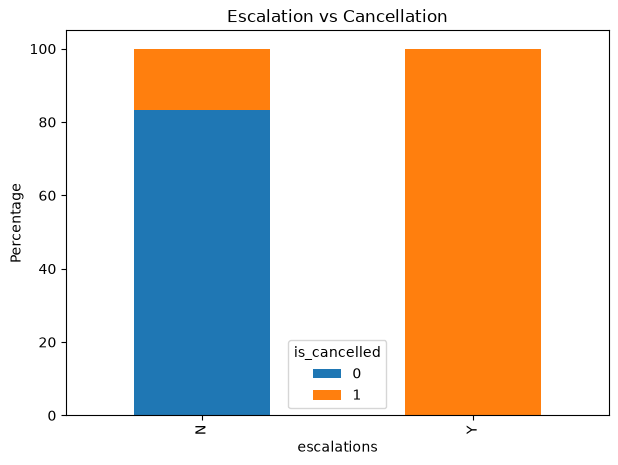

In [33]:
escalation = pd.crosstab(df['escalations'],df['is_cancelled'],normalize='index')*100
print(escalation)
escalation.plot(kind='bar',stacked=True,figsize=(7,5))
plt.ylabel("Percentage")
plt.title("Escalation vs Cancellation")
plt.show()

**Observation:** Escalations are close to a perfect churn predictor: only **16.7%** of non-escalated accounts cancel, but **100%** of escalated accounts cancel.

**Business recommendation:** Treat any support escalation as a save-at-all-costs event — every escalated customer in this dataset left. A formal "escalation = executive/retention-team review within 24 hours" policy is directly justified by this number.

## 4. Statistical Relationships Between Metrics

In [34]:
df.describe()

,cancellation_date,monthly_charges,cltv,churn_score,complaint_date,csat_score,is_cancelled,has_complaint
count,8,23.000000,23.000000,23.000000,9,9.000000,23.000000,23.000000
mean,2024-08-15 18:00:00,18.511739,803.739130,47.782609,2024-08-24 13:20:00,40.555556,0.347826,0.391304
min,2024-02-28 00:00:00,6.990000,42.000000,3.000000,2024-01-20 00:00:00,10.000000,0.000000,0.000000
25%,2024-08-08 00:00:00,12.990000,235.000000,16.500000,2024-08-28 00:00:00,20.000000,0.000000,0.000000
50%,2024-09-12 00:00:00,13.990000,640.000000,41.000000,2024-09-13 00:00:00,30.000000,0.000000,0.000000
75%,2024-09-25 18:00:00,19.490000,1150.000000,81.000000,2024-09-27 00:00:00,60.000000,1.000000,1.000000
max,2024-11-15 00:00:00,92.990000,2185.000000,99.000000,2025-03-18 00:00:00,90.000000,1.000000,1.000000
std,NaN,16.975570,662.545382,34.226460,NaN,31.666667,0.486985,0.499011


**Observation:** Median CLTV (₹640) sits well below the mean (₹804), and the 75th percentile churn score (81) is far above the median (41) — both distributions are right-skewed, meaning a handful of high-value or high-risk customers pull the averages up. Medians are safer than means to quote when summarizing this dataset in a business review.

In [38]:
df[numeric].corr()

,monthly_charges,cltv,churn_score,csat_score
monthly_charges,1.000000,0.610797,-0.390101,0.480569
cltv,0.610797,1.000000,-0.657395,0.099198
churn_score,-0.390101,-0.657395,1.000000,-0.468929
csat_score,0.480569,0.099198,-0.468929,1.000000


**Observation:** `churn_score` is **negatively correlated** with both `cltv` (-0.66) and `csat_score` (-0.47), and `monthly_charges` is **positively correlated** with `cltv` (0.61).

**Business recommendation:** `churn_score` appears to already be a reasonably good composite risk signal — high scores line up with lower satisfaction and lower lifetime value, which is exactly the pattern a good churn model should show. This is worth validating with an actual predictive model (see Next Steps) rather than only descriptive correlation.




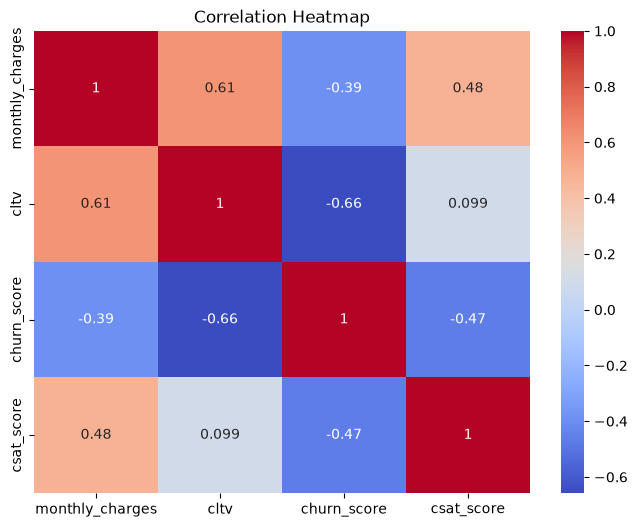

In [37]:
numeric = ['monthly_charges','cltv','churn_score','csat_score']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric].corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Observation**: The correlation heatmap indicates that most variables have weak correlations, while a few exhibit moderate positive or negative relationships. No severe multicollinearity is observed among the numerical features.

**Business recommendation**: Prioritize variables with stronger correlations when developing churn prediction models and monitor these key indicators regularly to identify customers at risk of cancellation.

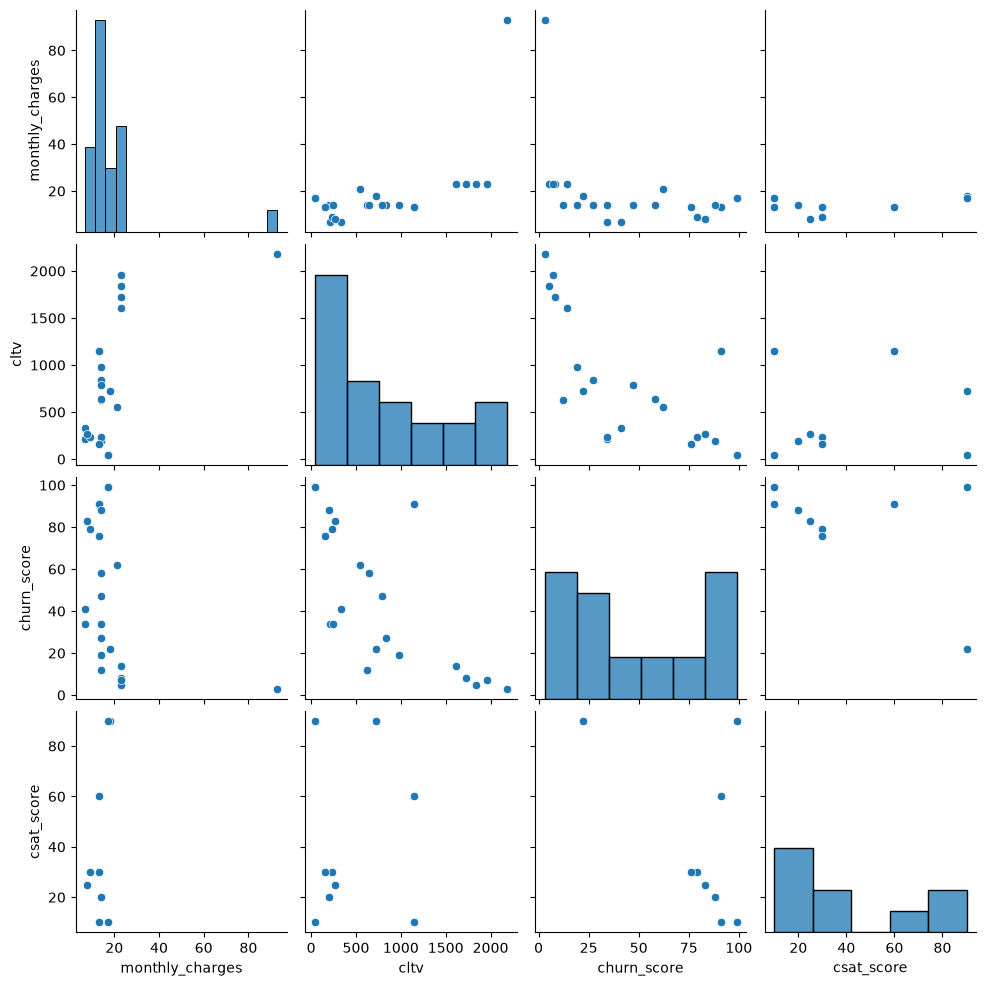

In [39]:
numeric_cols = ['monthly_charges', 'cltv', 'churn_score', 'csat_score']
sns.pairplot(df[numeric_cols], diag_kind='hist')
plt.show()

**Observation**: The pairplot reveals the distribution of key numerical variables and their pairwise relationships. Most variable pairs show weak to moderate relationships, while a few variables exhibit visible clustering and correlation patterns

**Business recommendation**: Focus predictive modeling and customer segmentation on variables with stronger relationships, such as customer satisfaction, monthly charges, and customer lifetime value. Continue collecting behavioral data to improve model performance.

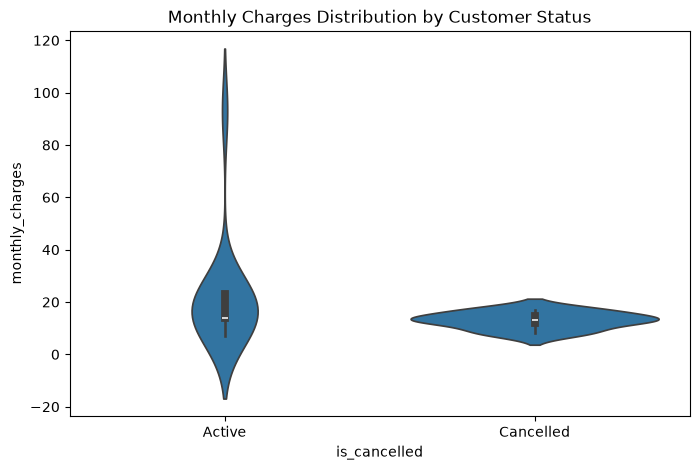

In [40]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df,x='is_cancelled', y='monthly_charges')
plt.xticks([0,1], ['Active', 'Cancelled'])
plt.title('Monthly Charges Distribution by Customer Status')
plt.show()

**Observation:** Same story as the boxplot in section 2 (cancelled customers cluster at lower monthly charges), shown here as a distribution shape rather than a single median line — useful to keep both if this becomes a slide deck, since some audiences read violin plots more easily than boxplots.

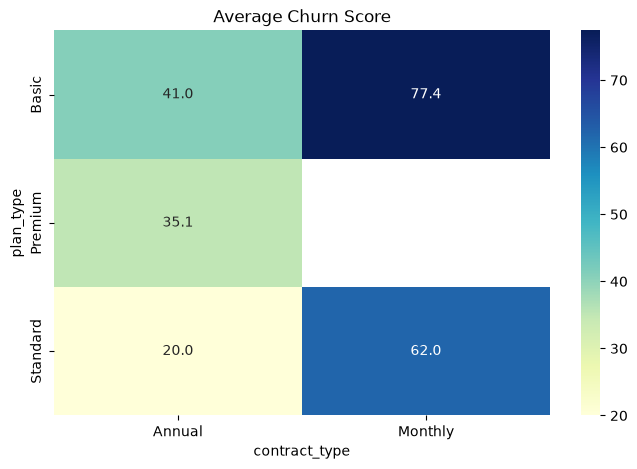

In [138]:
pivot = pd.pivot_table(df,values='churn_score',index='plan_type',columns='contract_type',aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot,annot=True,cmap='YlGnBu',fmt='.1f')
plt.title('Average Churn Score')
plt.show()

**Observation:** *Read the annotated heatmap values once re-run — call out which plan_type × contract_type combination has the highest average churn_score.* This is the most actionable cell in the notebook for a retention team, since it tells them exactly which plan+contract combination to prioritize first, rather than treating plan and contract as separate levers.

## 5. Revenue & Customer Value

  subscription_type  Average_CLTV
0           Organic    928.888889
1              Paid   1222.857143
2          Refferal    223.714286


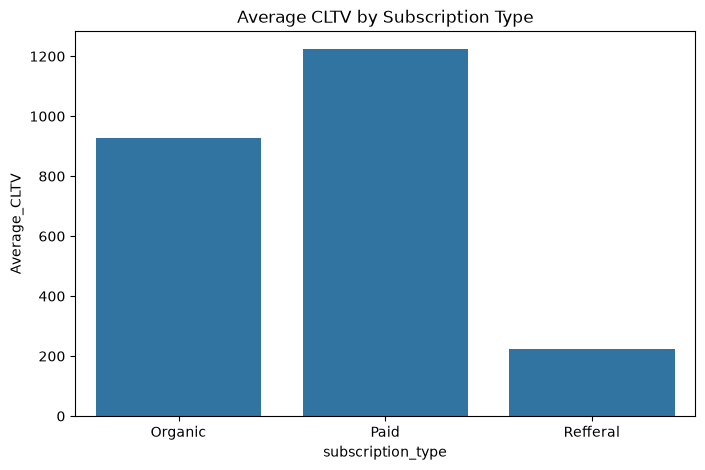

In [140]:
summary = df.groupby('subscription_type').agg(Average_CLTV=('cltv', 'mean')).reset_index()
print(summary)
plt.figure(figsize=(8,5))
sns.barplot(data=summary,x='subscription_type',y='Average_CLTV')
plt.title('Average CLTV by Subscription Type')
plt.show()

**Observation:** **Paid acquisition** customers have the highest average CLTV (₹1,223), ahead of Organic (₹929) — and **Referral** customers are lowest by a wide margin (₹224).

**Business recommendation:** This is counterintuitive and worth double-checking with more data: referral customers are usually assumed to be higher-value, not lower. If it holds up at scale, it suggests either the referral program is attracting low-fit customers or referral customers are being under-served post-signup. Compare against the referral cancellation rate in section 2 before changing the referral program.

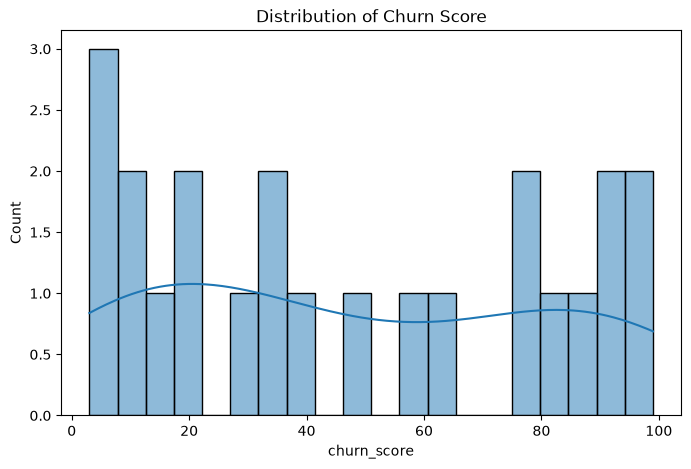

In [117]:
plt.figure(figsize=(8,5))
sns.histplot(df['churn_score'],bins=20,kde=True)
plt.title("Distribution of Churn Score")
plt.show()

**Observation**: The churn score distribution indicates that customers are spread across different levels of churn risk, with a concentration around specific score ranges.

**Business recommendation**: Develop an early warning system that automatically identifies customers with high churn scores and triggers personalized retention campaigns, such as loyalty offers or proactive customer support.

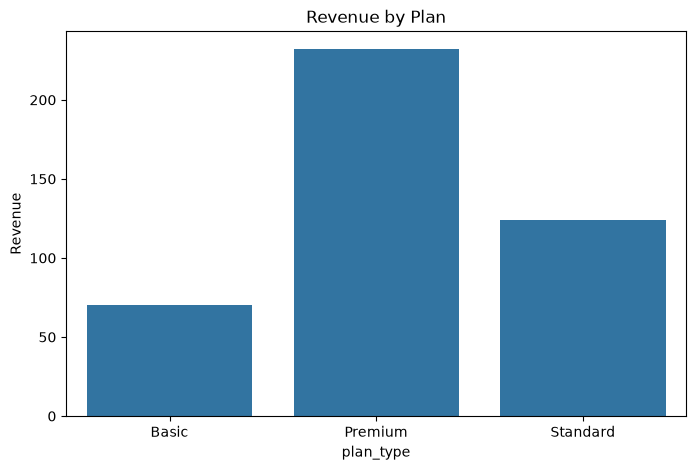

In [118]:
revenue = df.groupby('plan_type')['monthly_charges'].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=revenue.index,y=revenue.values)
plt.ylabel("Revenue")
plt.title("Revenue by Plan")
plt.show()

**Observation**: Revenue contribution varies across different subscription plans, indicating that some plans generate substantially higher revenue than others.

**Business recommendation**: Compare revenue with churn rate and Customer Lifetime Value (CLTV) for each plan. Focus marketing and retention efforts on plans that achieve both high revenue and strong customer retention, while improving the value proposition of underperforming plans.

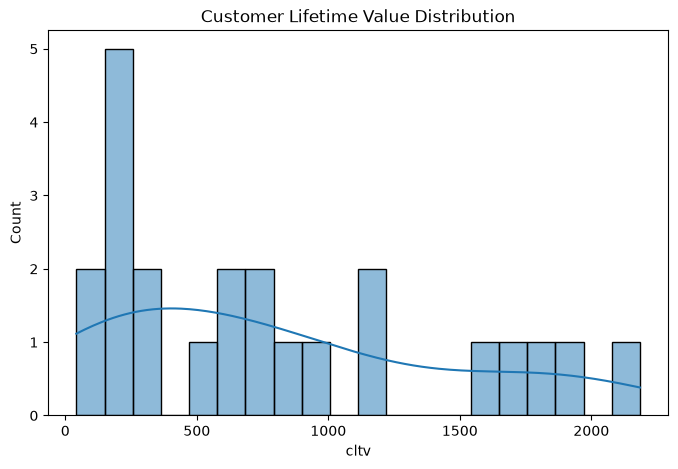

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df['cltv'],bins=20,kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.show()

**Observation:** *Note the shape — a long right tail here would mean a small number of very high-value customers who deserve a dedicated retention or account-management motion distinct from the general customer base.*

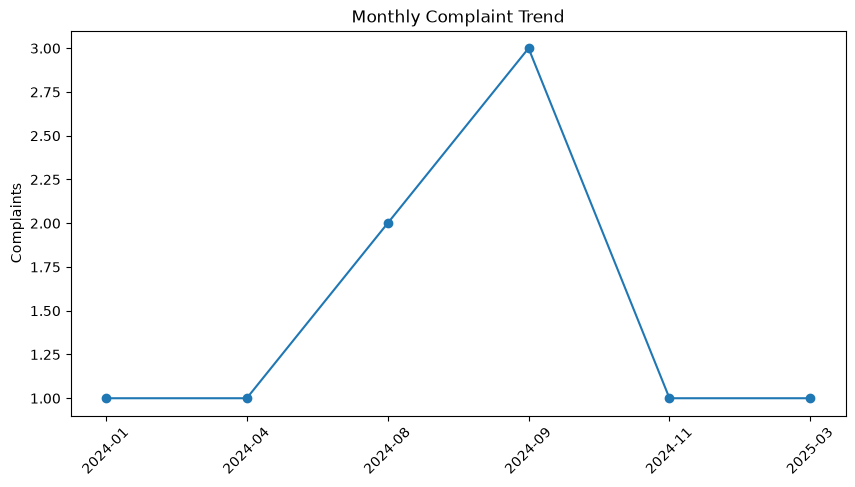

In [120]:
complaints = (df.dropna(subset=['complaint_date'])
                .groupby(df['complaint_date'].dt.to_period('M'))
                .size())

complaints.index = complaints.index.astype(str)
plt.figure(figsize=(10,5))
plt.plot(complaints.index,complaints.values,marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Complaint Trend")
plt.ylabel("Complaints")
plt.show()

**Observation**: nThe number of customer complaints fluctuates across different months, indicating variations in customer experience over time.

**Business recommendation** :Investigate the root causes of complaint spikes, strengthen customer support during high-volume periods, and implement preventive measures to reduce recurring issues.

## 6. Executive Summary

In [ ]:
print("Total Customers :", len(df))
print("Active Customers :", (df['is_cancelled']==0).sum())
print("Cancelled Customers :", (df['is_cancelled']==1).sum())
print("Average CLTV :", round(df['cltv'].mean(),2))
print("Average Monthly Charges :", round(df['monthly_charges'].mean(),2))
print("Average CSAT :", round(df['csat_score'].mean(),2))
print("Complaint Rate :", round(df['has_complaint'].mean()*100,2),"%")
print("Cancellation Rate :", round(df['is_cancelled'].mean()*100,2),"%")

## 7. Business Recommendations (Summary)

1. **Escalations and complaints are the clearest churn signals in the data** (88.9% and 100% cancellation rates respectively) — turn both into automatic retention-team triggers rather than standard support tickets.
2. **Push Monthly-contract customers toward Annual** — 60% vs 15.4% cancellation is the largest single lever available.
3. **Fix the Basic-plan value gap**, not the pricing — Basic churns 3x more than other plans despite cancelled customers paying *less* on average, ruling out simple price sensitivity.
4. **Anchor any retention-program business case to the ₹611 CLTV gap** between active and cancelled customers (₹1,016 vs ₹405), not just the churn rate, when pitching budget to leadership.
5. **Re-examine the referral acquisition channel** — referral customers show the lowest CLTV of any channel, which runs counter to the usual assumption that referrals are higher-quality.
6. **Investigate the September cancellation spike** against internal change logs (pricing, outages, competitor activity).

## 8. Limitations & Next Steps

- **Sample size (n=23):** every percentage above should be treated as directional. Before using this to make pricing or retention-budget decisions, re-run this notebook on the full customer base and check that subgroup sizes (e.g. per-country, per-gender) are large enough to trust.
- **No significance testing yet:** a chi-square test (for the categorical drivers like contract type, complaints, escalations) and a t-test or Mann-Whitney U test (for CLTV/monthly_charges differences) would turn "Basic churns more" into "Basic churns significantly more, p<0.05" — much stronger for a portfolio piece and for a real stakeholder conversation.
- **No predictive model yet:** everything here is descriptive. A logistic regression or gradient-boosted model (e.g. `churn_score`, `contract_type`, `has_complaint`, `escalations`, `monthly_charges` → `is_cancelled`) with a feature-importance chart would be a strong addition and is a natural "part 2" for this notebook.
- **Feature engineering opportunities:** customer tenure (`renewal_date` / today − `subscription_start_date`), customer age (from `dob`), and days-to-first-complaint would all likely sharpen the churn story.
- **Reproducibility:** the data load uses a hardcoded local Windows path. For a portfolio repo, include the (anonymized) dataset in the repo and load it with a relative path, or load from a public URL, so anyone can clone and run this end-to-end.
